# Tarefa 12


### Integrantes do grupo

*   Yasmin Agatha Acosta — 16905367
*   Yasmin Dos Santos Almeida — 16992205
*   Yasmin Victoria Ferreira Monteiro — 17068161

**Objetivo:** apresentar e exemplificar, por meio de um script em Python, os conceitos introdutórios de variável aleatória, variáveis discretas e contínuas, e os modelos de Bernoulli, Binomial e Poisson, com exemplos aplicados a produção, processamento, controle de qualidade, análise sensorial, segurança de alimentos, armazenamento e comercialização de produtos alimentícios.

Este notebook está organizado nas seguintes seções:

*   **Controle Microbiológico:** Aplicação das distribuições de Bernoulli e Binomial para análise de contaminação em amostras de leite.
*   **Embalagens Abaixo do Peso:** Análise de probabilidade usando a distribuição Binomial para controle de qualidade de embalagens.
*   **Falhas no Processamento:** Utilização da distribuição de Poisson para modelar ocorrências de falhas operacionais.
*   **Identificação de Modelos Probabilísticos:** Comparação e justificativa para a escolha de distribuições Bernoulli, Binomial e Poisson em diferentes situações.

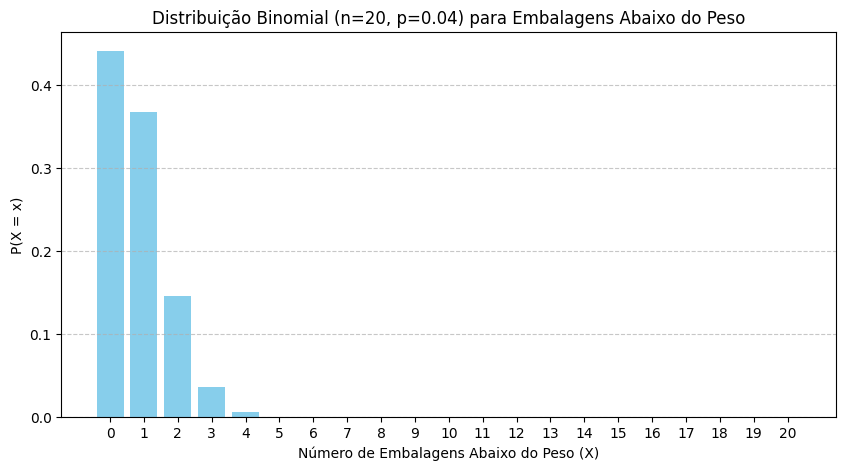

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# Parâmetros da distribuição Binomial para 'Embalagens abaixo do peso'
p_embalagem = 0.04   # probabilidade de embalagem abaixo do peso
n_embalagem = 20     # número de embalagens inspecionadas

# Valores possíveis para X (número de embalagens abaixo do peso)
x_embalagem = np.arange(0, n_embalagem + 1)

# Calcula a PMF para cada valor de x
pmf_embalagem = binom.pmf(x_embalagem, n_embalagem, p_embalagem)

# Cria o gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(x_embalagem, pmf_embalagem, color='skyblue')
plt.xlabel('Número de Embalagens Abaixo do Peso (X)')
plt.ylabel('P(X = x)')
plt.title(f'Distribuição Binomial (n={n_embalagem}, p={p_embalagem}) para Embalagens Abaixo do Peso')
plt.xticks(x_embalagem)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O gráfico acima visualiza a distribuição de probabilidade para o número de embalagens abaixo do peso. É possível observar os valores de probabilidade para cada número possível de embalagens fora do padrão, facilitando a identificação dos eventos mais e menos prováveis.

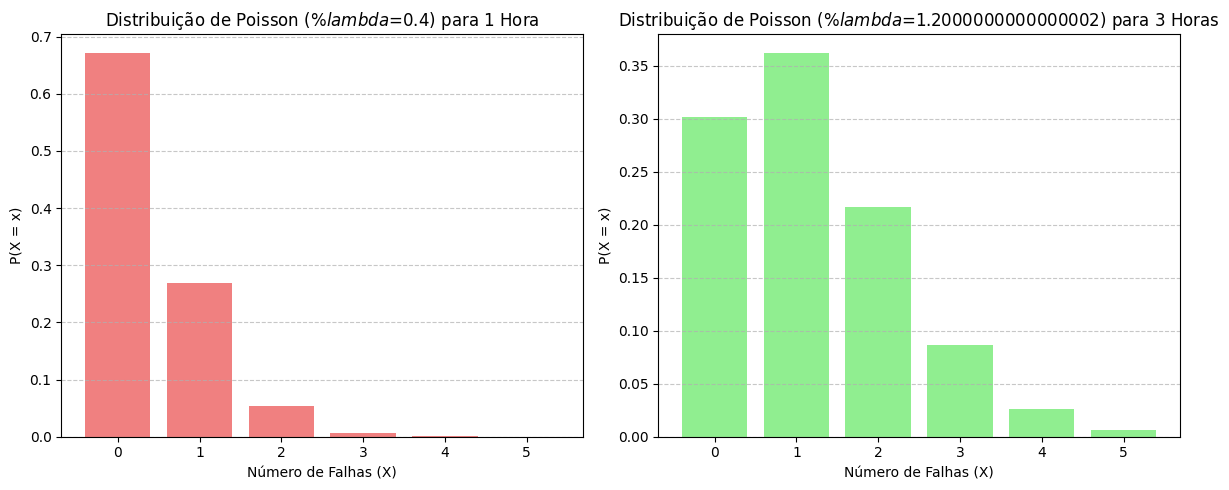

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

# Parâmetros da distribuição de Poisson para 'Falhas durante o processamento'
lambda_1h = 0.4  # taxa média de falhas por hora
lambda_3h = lambda_1h * 3 # taxa média de falhas para 3 horas

# Valores possíveis para X (número de falhas) - vamos considerar até 5 falhas para visualização
x_falhas = np.arange(0, 6)

# Calcula a PMF para cada valor de x (1 hora)
pmf_falhas_1h = poisson.pmf(x_falhas, lambda_1h)

# Cria o gráfico de barras para 1 hora
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
plt.bar(x_falhas, pmf_falhas_1h, color='lightcoral')
plt.xlabel('Número de Falhas (X)')
plt.ylabel('P(X = x)')
plt.title(r'Distribuição de Poisson ($\%lambda$='f'{lambda_1h}'r') para 1 Hora')
plt.xticks(x_falhas)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calcula a PMF para cada valor de x (3 horas)
pmf_falhas_3h = poisson.pmf(x_falhas, lambda_3h)

# Cria o gráfico de barras para 3 horas
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
plt.bar(x_falhas, pmf_falhas_3h, color='lightgreen')
plt.xlabel('Número de Falhas (X)')
plt.ylabel('P(X = x)')
plt.title(r'Distribuição de Poisson ($\%lambda$='f'{lambda_3h}'r') para 3 Horas')
plt.xticks(x_falhas)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Os gráficos acima ilustram a distribuição de probabilidade para o número de falhas no processamento, tanto para 1 hora quanto para 3 horas. É possível notar visualmente como o aumento do parâmetro $\lambda$ (devido ao maior período de observação) desloca a distribuição, tornando mais prováveis números maiores de falhas e diminuindo a probabilidade de zero falhas.

=== PARTE 1: X ~ Bernoulli(0,08) ===
P(X = 1) = P(contaminada)     = 0.08
P(X = 0) = P(não contaminada) = 0.92
E(X)   = 0.08
Var(X) = 0.0736

=== PARTE 2: Y ~ Binomial(20; 0,08) ===
E(Y)   = n*p       = 1.60
Var(Y) = n*p*(1-p) = 1.472

P(Y = 0) = 0.1887  (≈ 18.9%)
Conferência: 0.92**20 = 0.1887
P(Y = 0) = 0.1887
P(Y = 1) = 0.3282
P(Y = 2) = 0.2711
P(Y = 3) = 0.1414
P(Y = 4) = 0.0523
P(Y = 5) = 0.0145


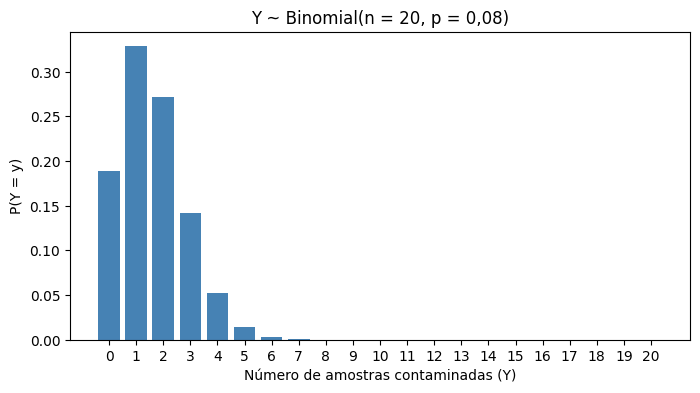

In [8]:
from scipy.stats import bernoulli, binom
import numpy as np
import matplotlib.pyplot as plt

p = 0.08   # probabilidade de contaminação
n = 20     # número de amostras independentes

# ---------------- PARTE 1: uma única amostra ----------------
# X ~ Bernoulli(p = 0,08), X ∈ {0, 1}

print("=== PARTE 1: X ~ Bernoulli(0,08) ===")
print(f"P(X = 1) = P(contaminada)     = {bernoulli.pmf(1, p):.2f}")
print(f"P(X = 0) = P(não contaminada) = {bernoulli.pmf(0, p):.2f}")
print(f"E(X)   = {bernoulli.mean(p):.2f}")
print(f"Var(X) = {bernoulli.var(p):.4f}")

# ---------------- PARTE 2: 20 amostras ----------------
# Y ~ Binomial(n = 20, p = 0,08), Y ∈ {0, 1, ..., 20}

print("\n=== PARTE 2: Y ~ Binomial(20; 0,08) ===")
print(f"E(Y)   = n*p       = {binom.mean(n, p):.2f}")
print(f"Var(Y) = n*p*(1-p) = {binom.var(n, p):.3f}")

# Questão 7: nenhuma amostra contaminada
p_zero = binom.pmf(0, n, p)
print(f"\nP(Y = 0) = {p_zero:.4f}  (≈ {p_zero*100:.1f}%)")
print(f"Conferência: 0.92**20 = {0.92**20:.4f}")

# Distribuição completa de Y
y = np.arange(0, n + 1)
pmf = binom.pmf(y, n, p)

for k in range(0, 6):
    print(f"P(Y = {k}) = {binom.pmf(k, n, p):.4f}")

plt.figure(figsize=(8, 4))
plt.bar(y, pmf, color="steelblue")
plt.xlabel("Número de amostras contaminadas (Y)")
plt.ylabel("P(Y = y)")
plt.title("Y ~ Binomial(n = 20, p = 0,08)")
plt.xticks(y)
plt.show()

### Respostas para Grupos 1 e 5: Controle Microbiológico

#### Variável Aleatória X (Análise de uma única amostra)

1.  **Defina uma variável aleatória X para representar o resultado da análise de uma única amostra. Quais valores X pode assumir?**
    *   A variável aleatória $X$ pode ser definida como:
        *   $X = 1$, se a amostra de leite estiver contaminada.
        *   $X = 0$, se a amostra de leite **não** estiver contaminada.
    *   Os valores que $X$ pode assumir são, portanto, $X \in \{0, 1\}$.

2.  **Qual distribuição de probabilidade pode ser utilizada para representar X? Identifique seu parâmetro e justifique sua escolha.**
    *   A distribuição de probabilidade que pode ser utilizada para representar $X$ é a **Distribuição de Bernoulli**.
    *   Seu único parâmetro é $p$, a probabilidade de "sucesso" (neste caso, a probabilidade de a amostra estar contaminada).
    *   No problema, $p = 0.08$.
    *   **Justificativa:** A Distribuição de Bernoulli é adequada para representar o resultado de um único experimento que possui apenas dois resultados possíveis (sucesso/fracasso ou contaminado/não contaminado) com uma probabilidade fixa de sucesso.

#### Interpretação de E(X)

4.  **Determine E(X). O que esse valor representa neste contexto?**
    *   O valor de $E(X)$ é 0.08 (conforme calculado no código Python acima).
    *   **Interpretação:** Neste contexto, $E(X) = 0.08$ representa a proporção esperada de amostras contaminadas ao longo de muitas análises de amostras únicas. Ou seja, em média, espera-se que 8% das amostras individuais analisadas estejam contaminadas.

#### Variável Aleatória Y (Análise de 20 amostras independentes)

5.  **Quais valores a variável aleatória Y pode assumir?**
    *   A variável aleatória $Y$ representa o número de amostras contaminadas entre as 20 avaliadas. Portanto, $Y$ pode assumir qualquer valor inteiro de 0 a 20 (inclusive).
    *   Os valores que $Y$ pode assumir são $Y \in \{0, 1, 2, \dots, 20\}$.

6.  **Qual distribuição de probabilidade pode ser utilizada para representar Y? Identifique seus parâmetros e justifique sua escolha.**
    *   A distribuição de probabilidade que pode ser utilizada para representar $Y$ é a **Distribuição Binomial**.
    *   Seus parâmetros são:
        *   $n = 20$: o número de ensaios independentes (o número total de amostras analisadas).
        *   $p = 0.08$: a probabilidade de sucesso em cada ensaio (a probabilidade de uma única amostra estar contaminada).
    *   **Justificativa:** A Distribuição Binomial é apropriada porque ela modela o número de sucessos (amostras contaminadas) em um número fixo de ensaios independentes ($n=20$), onde cada ensaio tem apenas dois resultados possíveis (contaminado/não contaminado) e uma probabilidade constante de sucesso ($p=0.08$).

#### Comparação entre X e Y

8.  **Compare as variáveis aleatórias X e Y. Explique por que, embora ambas estejam relacionadas à ocorrência de contaminação, elas são representadas por distribuições de probabilidade diferentes.**
    *   **X (Bernoulli):** Representa o resultado de um *único* ensaio (uma única amostra). Ela indica se o evento de contaminação ocorreu ou não para aquela amostra específica. É uma variável "tudo ou nada".
    *   **Y (Binomial):** Representa a *contagem* de sucessos (amostras contaminadas) em um *número fixo de ensaios independentes* ($n=20$). É uma agregação de múltiplos resultados de Bernoulli.

    *   **Razão para distribuições diferentes:** Ambas as variáveis estão relacionadas à contaminação, mas descrevem diferentes aspectos do experimento:
        *   A **Bernoulli** modela um *único evento* (contaminação de uma amostra).
        *   A **Binomial** modela o *número total de ocorrências* desse evento em uma *série de eventos independentes*.

    *   Em essência, a distribuição Binomial ($Y$) pode ser vista como a soma de $n$ variáveis de Bernoulli independentes e identicamente distribuídas ($X$). Por isso, elas são representadas por distribuições distintas que servem para modelar diferentes escalas e tipos de observações sobre o mesmo fenômeno subjacente de contaminação.